# Poetry metadata

summary of `data/poetry_metadata.csv`

Load the metadata table and print how many poem records it contains.

In [56]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
CSV_PATH = REPO_ROOT / "data" / "poetry_metadata.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Poem records (rows): {len(df):,}")

Poem records (rows): 312,988


We show every column and the percentage of rows where that column is non-missing.

In [27]:
def pct_non_null(series: pd.Series) -> float:
    s = series
    if s.dtype == object:
        empty = s.astype(str).str.strip().isin(["", "nan", "None"])
        return float(100 * (~s.isna() & ~empty).mean())
    return float(100 * s.notna().mean())

coverage = pd.DataFrame(
    {"pct_non_null": [pct_non_null(df[c]) for c in df.columns]},
    index=df.columns,
)
coverage["pct_non_null"] = coverage["pct_non_null"].round(1)
coverage

,pct_non_null
title_id,100.0
filename,100.0
author_lastname,99.8
author_firstname,98.9
qid,96.0
wikidata_url,96.0
occupation_wd,94.6
date_of_birth_wd,93.5
date_of_death_wd,86.4
sex_or_gender_wd,94.1


This data inherits a _very_ noisy historical Chadwyck–Healey scrape: columns ending in `_origch` are the original values, kept for reference. But wherever you can, use the data in columns ending in `_wd`. E.g. `author_birth_origch` contains the original dob info from CH -- but that data is often contaminated/compromised; it contains last names, periods, floruit dates etc... (in other words: the 99.8pct non-null for that column is high only because data types are mixed in that column).

New columns add author facts reconciled from Wikidata; for dates of birth and death you should rely on `date_of_birth_wd` and `date_of_death_wd`, not `author_birth_origch` / `author_death_origch`.

Another new column that was added is `edition_year` (parsed carefully from `edition_text` that often ends with a pub year).

We count unique authors by joining surname and given name, then report how many of those names have a Wikidata `qid`.

In [47]:
def build_author_key(frame: pd.DataFrame) -> pd.Series:
    ln = frame["author_lastname"].fillna("").astype(str).str.strip()
    fn = frame["author_firstname"].fillna("").astype(str).str.strip()
    ln = ln.replace({"nan": ""})
    fn = fn.replace({"nan": ""})
    both = ln.ne("") & fn.ne("")
    ln_only = ln.ne("") & fn.eq("")
    fn_only = ln.eq("") & fn.ne("")
    key = pd.Series("", index=frame.index, dtype=object)
    key.loc[both] = ln[both] + ", " + fn[both]
    key.loc[ln_only] = ln[ln_only]
    key.loc[fn_only] = fn[fn_only]
    return key


def group_has_qid(s: pd.Series) -> bool:
    for v in s.dropna().astype(str).str.strip():
        if len(v) > 1 and v[0] in "Qq" and v[1:].isdigit():
            return True
    return False


df["author_key"] = build_author_key(df)
_df_auth = df[df["author_key"].ne("")].copy()
n_authors = _df_auth["author_key"].nunique()
by_author = _df_auth.groupby("author_key", sort=False)["qid"].agg(group_has_qid)
n_with_qid = int(by_author.sum())
pct_qid = 100.0 * n_with_qid / n_authors if n_authors else 0.0

print(f"Unique authors (name key): {n_authors:,}")
print(f"With a Wikidata qid:       {n_with_qid:,}  ({pct_qid:.1f}%)")

Unique authors (name key): 3,630
With a Wikidata qid:       2,713  (74.7%)


We drop every row whose author has a Wikidata date of birth strictly after 1920, since the PPA horizon is roughly pre-1930; birth years are read from the ISO date string so we stay clear of pandas stupid datetime limit.

In [48]:
def birth_year_from_iso(s: pd.Series) -> pd.Series:
    t = s.astype(str).str.strip().replace({"": pd.NA, "nan": pd.NA})
    m = t.str.extract(r"^(-?)(\d{4})-", expand=True)
    y = pd.to_numeric(m[1], errors="coerce")
    return y.where(m[0] != "-", -y)


df["birth_year_wd"] = birth_year_from_iso(df["date_of_birth_wd"])
_named = df["author_key"].ne("")
by_birth = (
    df.loc[_named]
    .groupby("author_key", sort=False)["birth_year_wd"]
    .max()
)
late_authors = set(by_birth.index[by_birth > 1920])
df_ppa = df[~df["author_key"].isin(late_authors)].copy()

print(f"Rows before filter: {len(df):,}")
print(f"Rows after filter:  {len(df_ppa):,}")
print(f"Unique authors dropped (any DOB year > 1920): {len(late_authors):,}")

Rows before filter: 312,988
Rows after filter:  262,799
Unique authors dropped (any DOB year > 1920): 338


On this PPA-focused slice we recount distinct authors and the share that still carry a Wikidata identifier.

In [49]:
_ppa_auth = df_ppa[df_ppa["author_key"].ne("")].copy()
n_authors_ppa = _ppa_auth["author_key"].nunique()
by_author_ppa = _ppa_auth.groupby("author_key", sort=False)["qid"].agg(group_has_qid)
n_with_qid_ppa = int(by_author_ppa.sum())
pct_qid_ppa = 100.0 * n_with_qid_ppa / n_authors_ppa if n_authors_ppa else 0.0

print(f"PPA-focused unique authors: {n_authors_ppa:,}")
print(f"With a Wikidata qid:        {n_with_qid_ppa:,}  ({pct_qid_ppa:.1f}%)")

PPA-focused unique authors: 3,292
With a Wikidata qid:        2,375  (72.1%)


So, roughly thirty percent of the unique poets do not have a Qid assigned to them; here are the five name keys with the most poem rows among authors still missing a Wikidata id.

In [50]:
no_qid = by_author_ppa.index[~by_author_ppa]
top_no_qid = (
    _ppa_auth[_ppa_auth["author_key"].isin(no_qid)]
    .groupby("author_key", sort=False)
    .size()
    .sort_values(ascending=False)
    .head(5)
    .reset_index(name="rows")
)
top_no_qid

,author_key,rows
0,"Ward, Frederick William Orde",1936
1,"Ellison, Henry",1622
2,"Heath, Robert",287
3,"Douglas, Evelyn",258
4,"Goddard, William",236


We tabulate Wikidata `sex_or_gender_wd` for one row per PPA-focused author and show counts, percent of all such authors, and a bar chart.

,count,pct_of_authors
sex_or_gender_wd,,
male,1944,59.1
(missing),1032,31.3
female,316,9.6


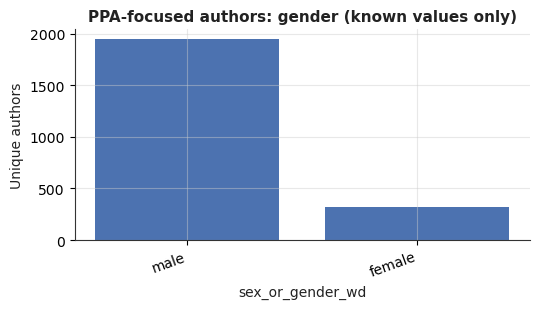

In [51]:
import numpy as np
from IPython.display import display


def _ppa_plot_style():
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "#333333",
            "axes.labelcolor": "#222222",
            "text.color": "#222222",
            "axes.grid": True,
            "grid.color": "#cccccc",
            "grid.linestyle": "-",
            "grid.alpha": 0.45,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.titleweight": "600",
        }
    )


_ppa_plot_style()

_poet_ppa = (
    _ppa_auth.sort_values("edition_year", na_position="last")
    .drop_duplicates("author_key", keep="first")
    .copy()
)

g = _poet_ppa["sex_or_gender_wd"].fillna("").astype(str).str.strip()
g = g.replace({"nan": ""})
g_display = g.where(g.ne(""), "(missing)")
gender_tab = g_display.value_counts().to_frame("count")
gender_tab["pct_of_authors"] = (100 * gender_tab["count"] / len(_poet_ppa)).round(1)
display(gender_tab)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
_gplot = gender_tab.drop(index="(missing)", errors="ignore")
ax.bar(_gplot.index.astype(str), _gplot["count"].values, color="#4c72b0", edgecolor="none")
ax.set_ylabel("Unique authors")
ax.set_xlabel("sex_or_gender_wd")
ax.set_title("PPA-focused authors: gender (known values only)")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
plt.show()


We histogram wikidata birth years from the same one-row-per-author table (20-year bins, years from 1000 CE onward).

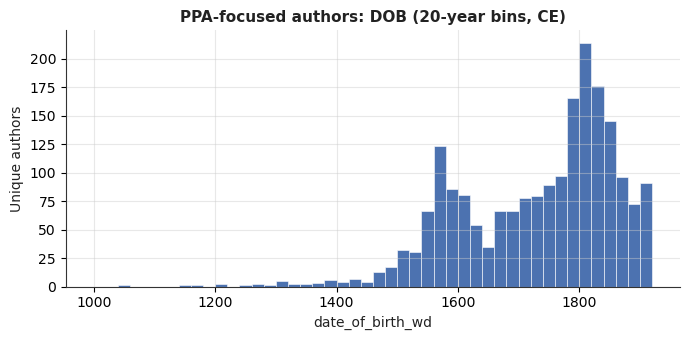

In [52]:
_ppa_plot_style()
y = _poet_ppa["birth_year_wd"].dropna()
y = y[y >= 1000]
bin_edges = np.arange(1000, 1931, 20)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=bin_edges, color="#4c72b0", edgecolor="white", linewidth=0.4)
ax.set_xlabel("date_of_birth_wd")
ax.set_ylabel("Unique authors")
ax.set_title("PPA-focused authors: DOB (20-year bins, CE)")
fig.tight_layout()
plt.show()


We count how many poem rows fall into each `period` label (raw corpus counts).

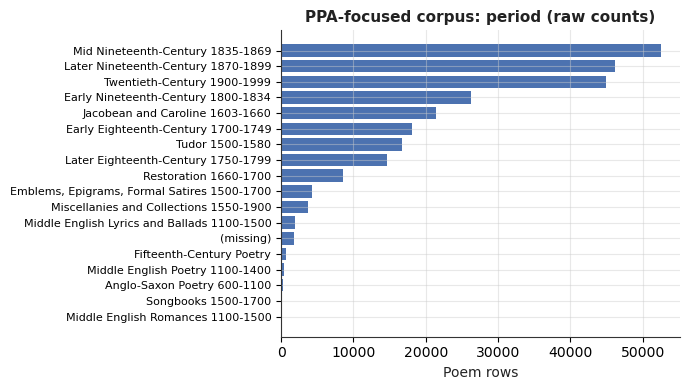

In [53]:
_ppa_plot_style()
pc = df_ppa["period"].fillna("(missing)").astype(str).str.strip()
pc = pc.replace({"": "(missing)", "nan": "(missing)"})
tab = pc.value_counts()
fig, ax = plt.subplots(figsize=(7, max(4, min(28, 0.22 * len(tab)))))
y = list(range(len(tab)))
ax.barh(y, tab.values, color="#4c72b0", edgecolor="none")
ax.set_yticks(y)
ax.set_yticklabels(list(tab.index), fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Poem rows")
ax.set_title("PPA-focused corpus: period (raw counts)")
fig.tight_layout()
plt.show()


We take the first citizenship label (text before `|`) from `country_of_citizenship_wd` on the same one-row-per-author table as gender (`_poet_ppa`), then count unique authors and show the 25 most frequent values.

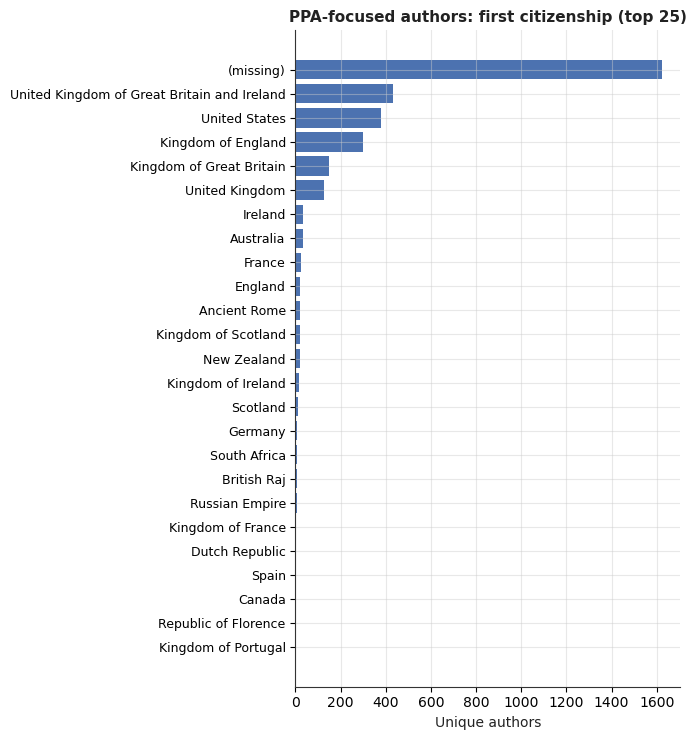

In [54]:
_ppa_plot_style()
cc = _poet_ppa["country_of_citizenship_wd"].fillna("").astype(str).str.strip()
cc = cc.replace({"nan": ""})
cc = cc.str.split("|").str[0].str.strip()
cc = cc.where(cc.ne(""), "(missing)")
tab = cc.value_counts().head(25)
fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(tab))))
y = list(range(len(tab)))
ax.barh(y, tab.values, color="#4c72b0", edgecolor="none")
ax.set_yticks(y)
ax.set_yticklabels(list(tab.index), fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Unique authors")
ax.set_title("PPA-focused authors: first citizenship (top 25)")
fig.tight_layout()
plt.show()


We take the first Wikidata occupation (text before `|`) per author and plot the twenty most common labels.

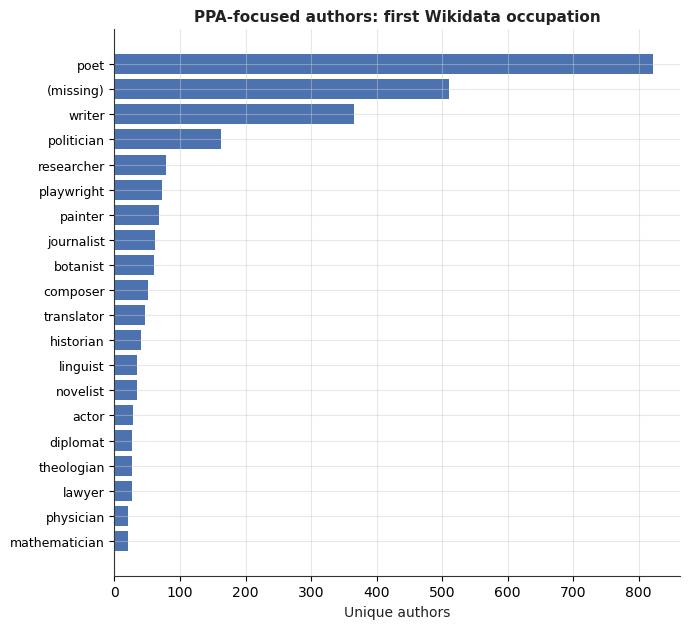

In [55]:
def primary_occupation(s):
    if pd.isna(s):
        return pd.NA
    t = str(s).strip()
    if not t or t.lower() == "nan":
        return pd.NA
    return t.split("|")[0].strip()


_ppa_plot_style()
prim = _poet_ppa["occupation_wd"].map(primary_occupation)
prim = prim.astype("string").fillna("(missing)")
prim = prim.astype(str).str.strip()
prim = prim.replace({"": "(missing)", "<NA>": "(missing)"})
tab = prim.value_counts().head(20)
fig, ax = plt.subplots(figsize=(7, max(3.5, 0.32 * len(tab))))
y = list(range(len(tab)))
ax.barh(y, tab.values, color="#4c72b0", edgecolor="none")
ax.set_yticks(y)
ax.set_yticklabels(list(tab.index), fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Unique authors")
ax.set_title("PPA-focused authors: first Wikidata occupation")
fig.tight_layout()
plt.show()


----